# 01 - Rotor and EPU Sizing

This notebook explores the propulsion system model in `evtolpy`: rotor geometry, disk loading, rotor solidity, and the parametric EPU (Electric Propulsion Unit) mass estimation.

The rotor system is the heart of eVTOL hover performance. From momentum theory, hover power scales as:

$$P_{hover} = T \cdot v_i = T \cdot \sqrt{\frac{T}{2 \rho A}}$$

where $T$ is thrust, $\rho$ is air density, and $A$ is total rotor disk area. This means **more disk area -> lower induced velocity -> less hover power**. But theres a trade off, larger rotors add structural mass and drag.

In [1]:
import sys
import math
sys.path.append('../../evtol')
from aircraft import Aircraft

aircraft = Aircraft('../../analysis/cfg-case-study/low-altitude-1500-ft/archer-midnight/30-miles/Archer-Midnight-1500-30.json')

## Rotor Configuration

The Archer Midnight uses a **tilt rotors with dedicated lift rotors** architecture:
- **Lift rotors** only active during hover, they turn off during wingborne flight
- **Tilt rotors** provide both hover thrust and forward propulsion, the transition phase is where they "tilt"


In [2]:
prop = aircraft.propulsion

print(f"Total Rotors:      {prop.rotor_count}")
print(f"  Lift Rotors:     {prop.lift_rotor_count}")
print(f"  Tilt Rotors:     {prop.tilt_rotor_count}")
print(f"Rotor Diameter:    {prop.rotor_diameter_m:.2f} m")
print(f"Rotor Efficiency:  {prop.rotor_effic:.2f}")
print(f"Tip Mach:          {prop.tip_mach:.2f}")
print(f"Average CL:        {prop.rotor_avg_cl:.3f}")
print(f"")
print(f"--- Derived ---")
single_disk = math.pi * (prop.rotor_diameter_m / 2.0) ** 2
print(f"Single Rotor Disk Area: {single_disk:.2f} m^2")
print(f"Total Disk Area:        {prop.disk_area_m2:.2f} m^2")

Total Rotors:      12
  Lift Rotors:     6
  Tilt Rotors:     6
Rotor Diameter:    2.00 m
Rotor Efficiency:  0.85
Tip Mach:          0.40
Average CL:        0.750

--- Derived ---
Single Rotor Disk Area: 3.14 m^2
Total Disk Area:        37.70 m^2


## Disk Loading and Rotor Solidity

**Disk loading** ($DL = W / A_{disk}$) is the most important rotor sizing parameter:
- Lower DL -> lower induced velocity -> less hover power (good)
- Lower DL -> larger rotor diameter -? more structural mass and stopped-rotor drag (bad)

**Rotor solidity** ($\sigma = N_b \cdot c / (\pi R)$) is the ratio of total blade area to disk area. It is derived from the thrust coefficient at hover:

$$C_T = \frac{T}{\rho A (\Omega R)^2} \qquad \sigma = \frac{C_T}{C_{L,avg} / \text{number of blades}}$$

Higher solidity means the blades are more heavily loaded.

In [3]:
N_P_M2_2_LB_P_FT2 = 0.0209

disk_loading = aircraft.max_takeoff_mass_kg / prop.disk_area_m2
print(f"Disk Loading: {disk_loading:.2f} kg/m^2")
print(f"              ({disk_loading * aircraft.environ.g_m_p_s2 * N_P_M2_2_LB_P_FT2:.2f} lb/ft^2)")
print(f"")
print(f"Rotor Solidity: {aircraft.rotor_solidity:.4f}")

Disk Loading: 84.22 kg/m^2
              (17.27 lb/ft^2)

Rotor Solidity: 0.2912


## EPU Mass Model

The EPU (Electric Propulsion Unit) includes the motor, inverter, and gearbox for each rotor. Its mass is estimated from an **empirical regression** based on:

- **Hover torque**: determined by thrust requirement and rotor RPM
- **Over-torque factor**: accounts for OEI conditions where remaining motors must increase output
- **Maximum RPM**: set by tip Mach limit to avoid compressibility losses

The over torque factor is a key design choice: higher redundancy (more rotors) means a lower over torque factor per motor, but more total motor count.

In [4]:
print(f"Over-Torque Factor:    {aircraft.over_torque_factor:.3f}")
print(f"Single EPU Mass:       {aircraft.single_epu_mass_kg:.2f} kg")
print(f"Total EPU Mass:        {aircraft.epu_mass_kg:.2f} kg ({prop.rotor_count} units)")

Over-Torque Factor:    1.500
Single EPU Mass:       30.27 kg
Total EPU Mass:        363.30 kg (12 units)


## Propulsion Mass Visualization

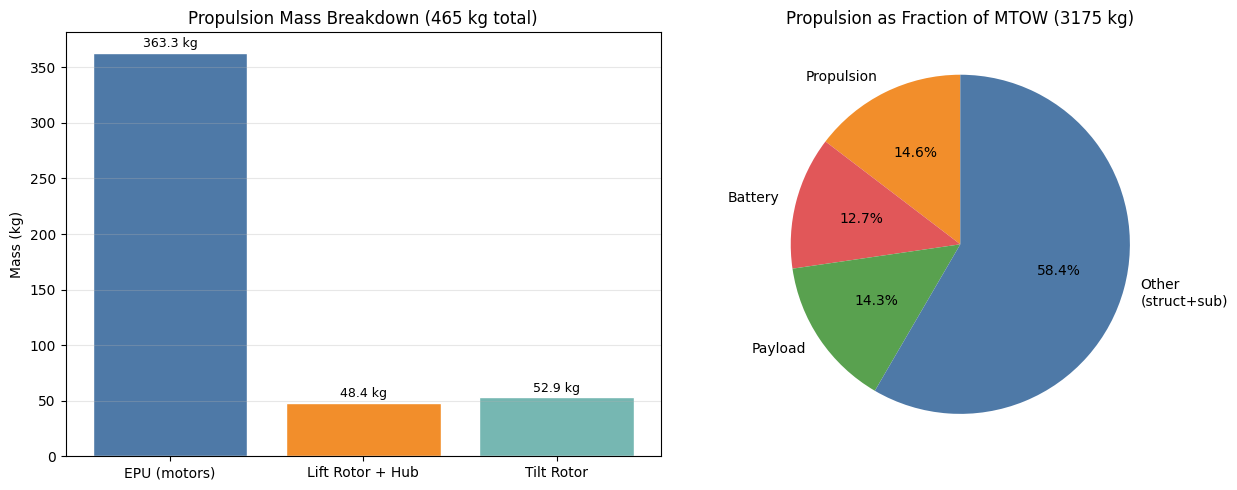

In [5]:
import matplotlib.pyplot as plt

total_prop = aircraft.epu_mass_kg + aircraft.lift_rotor_hub_mass_kg + aircraft.tilt_rotor_mass_kg

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Propulsion mass breakdown
labels = ['EPU (motors)', 'Lift Rotor + Hub', 'Tilt Rotor']
masses = [aircraft.epu_mass_kg, aircraft.lift_rotor_hub_mass_kg, aircraft.tilt_rotor_mass_kg]
colors = ['#4e79a7', '#f28e2b', '#76b7b2']
bars = ax1.bar(labels, masses, color=colors, edgecolor='white')
for bar, m in zip(bars, masses):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{m:.1f} kg', ha='center', va='bottom', fontsize=9)
ax1.set_ylabel('Mass (kg)')
ax1.set_title(f'Propulsion Mass Breakdown ({total_prop:.0f} kg total)')
ax1.grid(True, alpha=0.3, axis='y')

# Propulsion in context of MTOW
other_mass = aircraft.max_takeoff_mass_kg - total_prop - aircraft.battery_mass_kg - aircraft.payload_kg
groups = ['Propulsion', 'Battery', 'Payload', 'Other\n(struct+sub)']
group_masses = [total_prop, aircraft.battery_mass_kg, aircraft.payload_kg, other_mass]
group_colors = ['#f28e2b', '#e15759', '#59a14f', '#4e79a7']
wedges, texts, autotexts = ax2.pie(group_masses, labels=groups, autopct='%1.1f%%',
                                     colors=group_colors, startangle=90)
ax2.set_title(f'Propulsion as Fraction of MTOW ({aircraft.max_takeoff_mass_kg:.0f} kg)')

plt.tight_layout()
plt.show()

## Summary

Key propulsion sizing insights:

- **Disk loading** governs hover efficiency via momentum theory: $P \propto T^{3/2} / \sqrt{\rho A}$ lower disk loading -> less hover power, but larger rotors
- **Rotor solidity** links thrust requirements to blade geometry, it determines how heavily the blades are aerodynamically loaded
- **EPU mass** is estimated from an empirical model using hover torque and RPM, the over torque factor for OEI conditions is a key multiplier
- The propulsion system mass fraction feeds directly into the MTOW iteration loop

**Next:** [02 - Battery Sizing]